<a href="https://colab.research.google.com/github/safeai-snu/finance_ai_2025/blob/main/0508%EA%B8%88%EC%9C%B5%EC%97%B0%EC%88%98%EC%9B%90_%EC%BD%94%EB%93%9C%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Adversarial attack

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),            # convert to [0,1]
])
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [ ]:
# Define a Simple CNN
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())


In [ ]:
# Train the model
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.size(0)
        pred = output.argmax(dim=1)
        correct += pred.eq(target).sum().item()
    avg_loss = total_loss / len(train_loader.dataset)
    acc = correct / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}, Accuracy: {acc*100:.2f}%")

In [ ]:
# Evaluate on Clean Test Data
def evaluate(loader, model):
    model.eval()
    correct = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target).sum().item()
    return correct / len(loader.dataset)

clean_acc = evaluate(test_loader, model)
print(f"Test accuracy on clean examples: {clean_acc*100:.2f}%")

In [ ]:
# FGSM Adversarial Attack Implementation
def fgsm_attack(data, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_data = data + epsilon * sign_data_grad
    return torch.clamp(perturbed_data, 0, 1)

epsilon = 0.2  # attack strength

# Generate adversarial test examples
model.eval()
adversarial_examples = []
adversarial_labels = []

for data, target in test_loader:
    data, target = data.to(device), target.to(device)
    data.requires_grad = True
    output = model(data)
    loss = criterion(output, target)
    model.zero_grad()
    loss.backward()
    data_grad = data.grad.data
    perturbed_data = fgsm_attack(data, epsilon, data_grad)
    adversarial_examples.append(perturbed_data.detach().cpu())
    adversarial_labels.append(target.detach().cpu())

adversarial_data = torch.cat(adversarial_examples)
adversarial_targets = torch.cat(adversarial_labels)
adv_dataset = torch.utils.data.TensorDataset(adversarial_data, adversarial_targets)
adv_loader = DataLoader(adv_dataset, batch_size=batch_size, shuffle=False)


In [6]:
# Evaluate on Adversarial Examples
adv_acc = evaluate(adv_loader, model)
print(f"Test accuracy on adversarial examples (epsilon={epsilon}): {adv_acc*100:.2f}%")


In [ ]:
# Visualization of Sample Images
import random
num_display = 5
indices = random.sample(range(len(test_dataset)), num_display)

plt.figure(figsize=(10,4))
for i, idx in enumerate(indices):
    orig_img, label = test_dataset[idx]
    adv_img = adversarial_data[idx]
    adv_pred = model(adv_img.unsqueeze(0).to(device)).argmax(dim=1).item()

    plt.subplot(2, num_display, i+1)
    plt.title(f"Orig: {label}")
    plt.imshow(orig_img.squeeze(), cmap='gray')
    plt.axis('off')

    plt.subplot(2, num_display, num_display + i + 1)
    plt.title(f"Adv: {adv_pred}")
    plt.imshow(adv_img.squeeze(), cmap='gray')
    plt.axis('off')

plt.suptitle("Original (top) vs. Adversarial (bottom) Examples")
plt.show()

# Differential privacy

In [ ]:
# Imports and Setup
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [ ]:
# Generate 2D Synthetic Gaussian Data
X, y = make_blobs(n_samples=300, centers=[[-2, -2], [2, 2]], cluster_std=2.0, random_state=0)
X = StandardScaler().fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

tensor_X_train = torch.from_numpy(X_train).float().to(device)
tensor_y_train = torch.from_numpy(y_train).float().to(device)
tensor_X_test = torch.from_numpy(X_test).float().to(device)
tensor_y_test = torch.from_numpy(y_test).float().to(device)

train_dataset = torch.utils.data.TensorDataset(tensor_X_train, tensor_y_train)
batch_size = 64
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Define a Linear Binary Classifier
class LogisticModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)
    def forward(self, x):
        return torch.sigmoid(self.linear(x)).squeeze()


In [ ]:
# Manual DP-SGD Training Function
def train_with_dp(model, loader, criterion, optimizer, epsilon, delta=1e-5, max_grad_norm=1.0, epochs=30):
    sigma = max_grad_norm * np.sqrt(2 * np.log(1.25 / delta)) / epsilon
    for epoch in range(epochs):
        model.train()
        for x_batch, y_batch in loader:
            optimizer.zero_grad()
            batch_size = x_batch.size(0)
            outputs = model(x_batch)
            losses = criterion(outputs, y_batch)
            grads = []
            for i in range(batch_size):
                optimizer.zero_grad()
                losses[i].backward(retain_graph=True)
                grad_vector = [p.grad.detach().view(-1) for p in model.parameters()]
                grads.append(torch.cat(grad_vector))
            grads = torch.stack(grads)
            norms = torch.norm(grads, dim=1)
            clipped = grads * (max_grad_norm / norms.clamp(min=max_grad_norm)).unsqueeze(1)
            avg_grad = clipped.mean(dim=0)
            noise = torch.randn_like(avg_grad) * sigma
            noisy_grad = avg_grad + noise
            pointer = 0
            for p in model.parameters():
                numel = p.numel()
                p.grad = noisy_grad[pointer:pointer+numel].view_as(p)
                pointer += numel
            optimizer.step()
    return model

In [ ]:
# Train models for different epsilons
eps_list = [float('inf'), 100.0, 10.0, 1.0, 0.1]
models = {}
for eps in eps_list:
    model = LogisticModel().to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    criterion = nn.BCELoss(reduction='none')
    if eps == float('inf'):
        for epoch in range(30):
            for x_batch, y_batch in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(x_batch), y_batch).mean()
                loss.backward()
                optimizer.step()
    else:
        model = train_with_dp(model, train_loader, criterion, optimizer, eps)
    models[eps] = model
    with torch.no_grad():
        preds = (model(tensor_X_test) > 0.5).float()
        acc = (preds == tensor_y_test).float().mean().item()
    print(f"ε={'∞' if eps==float('inf') else eps} → Test Accuracy: {acc*100:.2f}%")


Using device: cuda
ε=∞ → Test Accuracy: 92.22%
ε=100.0 → Test Accuracy: 90.00%
ε=10.0 → Test Accuracy: 92.22%
ε=1.0 → Test Accuracy: 48.89%
ε=0.1 → Test Accuracy: 41.11%


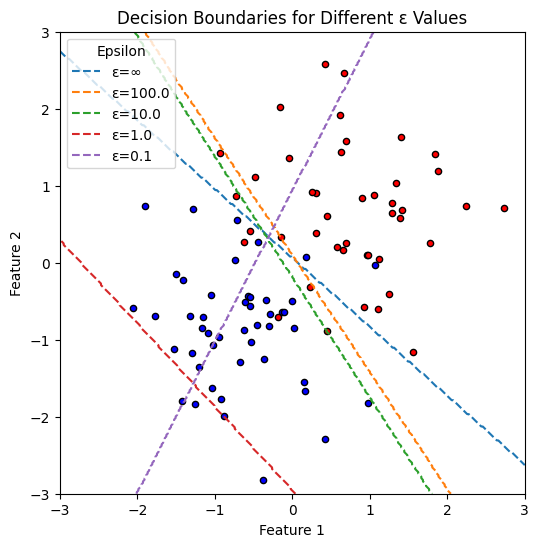

In [ ]:
# Overlay decision boundaries in one figure with distinct colors for each ε value
xx, yy = np.meshgrid(np.linspace(-3,3,300), np.linspace(-3,3,300))
grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float().to(device)

plt.figure(figsize=(6,6))
legend_handles = []
n_colors = len(models)
# Choose a colormap
cmap = plt.get_cmap('tab10')
for idx, (eps, model) in enumerate(models.items()):
    color = cmap(idx % n_colors)
    with torch.no_grad():
        Z = (model(grid) > 0.5).cpu().numpy().reshape(xx.shape)
    label = f"ε={'∞' if eps==float('inf') else eps}"
    # Plot contour line with specified color
    contour = plt.contour(xx, yy, Z, levels=[0.5], colors=[color], linewidths=1.5, linestyles='--')
    # Custom legend handle
    line = Line2D([0], [0], color=color, linestyle='--', linewidth=1.5)
    legend_handles.append((line, label))

# Plot data points without labels
plt.scatter(X_test[y_test==0,0], X_test[y_test==0,1], c='blue', edgecolors='k', s=20)#, alpha=0.5)
plt.scatter(X_test[y_test==1,0], X_test[y_test==1,1], c='red', edgecolors='k', s=20)#, alpha=0.5)

# Add legend for ε values
lines, labels = zip(*legend_handles)
plt.legend(lines, labels, title='Epsilon')

plt.title('Decision Boundaries for Different ε Values')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

# End script: 하나의 Figure에 ε별 결정 경계만 오버레이하여 비교합니다.
